<a href="https://colab.research.google.com/github/yarynauh/python_project_overview/blob/main/E_commerce_sales_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
import pandas as pd

auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")

query = """
WITH session_info AS (
  SELECT
    s.date AS session_date,
    s.ga_session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel
  FROM `DA.session` s
  LEFT JOIN `DA.session_params` sp
    ON s.ga_session_id = sp.ga_session_id
),

account_info AS (
  SELECT
    acs.ga_session_id,
    a.id AS account_id,
    a.is_verified,
    a.is_unsubscribed
  FROM `DA.account_session` acs
  LEFT JOIN `DA.account` a
    ON acs.account_id = a.id
),

order_info AS (
  SELECT
    o.ga_session_id,
    p.category AS product_category,
    p.name AS product_name,
    p.price AS product_price,
    p.short_description AS product_description
  FROM `DA.order` o
  LEFT JOIN `DA.product` p
    ON o.item_id = p.item_id
)

SELECT
  si.session_date,
  si.ga_session_id,
  si.continent,
  si.country,
  si.device,
  si.browser,
  si.mobile_model_name,
  si.operating_system,
  si.language,
  si.traffic_source,
  si.traffic_channel,
  ai.account_id,
  ai.is_verified,
  ai.is_unsubscribed,
  oi.product_category,
  oi.product_name,
  oi.product_price,
  oi.product_description
FROM session_info si
LEFT JOIN account_info ai
  ON si.ga_session_id = ai.ga_session_id
LEFT JOIN order_info oi
  ON si.ga_session_id = oi.ga_session_id
"""

query_job = client.query(query)
df = query_job.to_dataframe(create_bqstorage_client=False)

df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.2/265.2 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: google-cloud-bigquery
    Found existing installation: google-cloud-bigquery 3.42.2
    Uninstalling google-cloud-bigquery-3.42.2:
      Successfully uninstalled google-cloud-bigquery-3.42.2


,session_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,product_category,product_name,product_price,product_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [4]:
df.shape

(349545, 18)

In [6]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set_theme(style="whitegrid")

In [13]:
# 1. Basic dataset structure

print("Total number of rows:", df.shape[0])
print("Total number of columns:", df.shape[1])

print("\nData types per column:")
print(df.dtypes)

numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("\nNumeric columns:", numeric_cols)

categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("\nCategorical columns:", categorical_cols)

date_cols = ["session_date"]  # dbdate type is not caught by select_dtypes("datetime")
print("\nDate columns:", date_cols)

print("\nNumber of unique sessions:", df["ga_session_id"].nunique())
print("Date range: from", df["session_date"].min(), "to", df["session_date"].max())


# 2. Missing values: count, share

missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values(
    "missing_count", ascending=False
)
print("\nColumns with missing values:")
print(missing_report)


# 3. Duplicate rows check

print("\nFully duplicated rows:", df.duplicated().sum())


# 4. Check categorical columns for inconsistent formatting
# (extra spaces, case mismatches, near-duplicate categories)

cols_to_check = ["country", "device", "browser", "traffic_source",
                  "traffic_channel", "product_category"]

for col in cols_to_check:
    unique_vals = sorted(df[col].dropna().unique())
    print(f"\n{col} — {len(unique_vals)} unique values:")
    print(unique_vals)

Total number of rows: 349545
Total number of columns: 18

Data types per column:
session_date            dbdate
ga_session_id            Int64
continent               object
country                 object
device                  object
browser                 object
mobile_model_name       object
operating_system        object
language                object
traffic_source          object
traffic_channel         object
account_id               Int64
is_verified              Int64
is_unsubscribed          Int64
product_category        object
product_name            object
product_price          float64
product_description     object
dtype: object

Numeric columns: ['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'product_price']

Categorical columns: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'product_description']

Date columns: ['session_date

The dataset contains 349,545 rows and 18 columns (5 numeric, 12 categorical, 1 date), covering the period from 01.11.2020 to 31.01.2021. Missing values fall into three logical groups: (1) account_id, is_verified, is_unsubscribed — 92.01% missing, matching the share of sessions without user registration; (2) product_category, product_name, product_price, product_description — 90.41% missing, matching the share of sessions without a completed purchase; (3) language — 32.69% missing, likely because not all browsers report language settings. All missing values have a logical explanation and are not data-collection errors, so they should not be dropped or artificially filled — this correctly reflects real user behavior (most visitors don't register or buy immediately). No duplicate rows were found (0), and checking unique values in key categorical columns (country, device, browser, traffic_source, traffic_channel, product_category) revealed no formatting issues (extra whitespace, case mismatches, or near-duplicate categories).

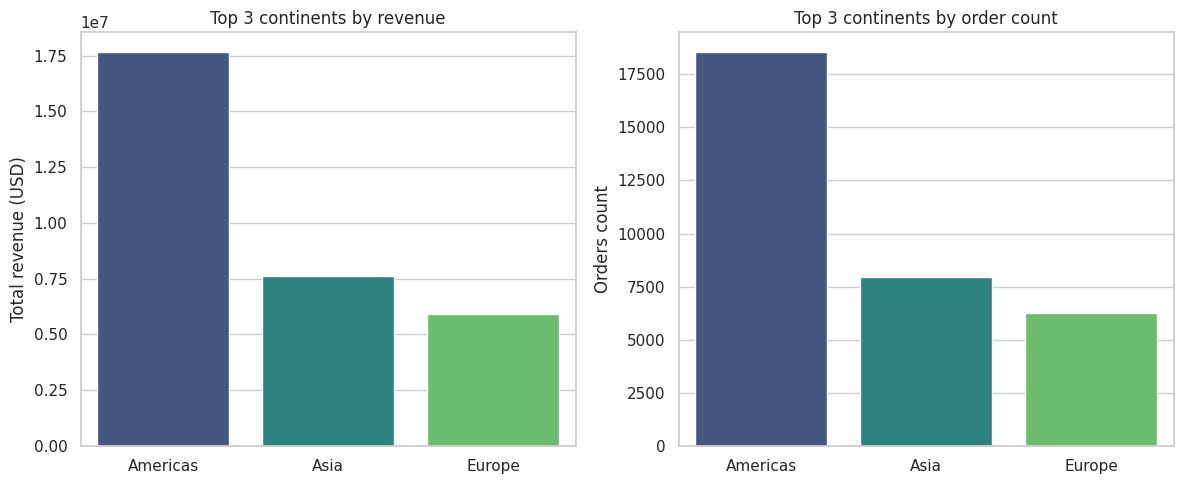

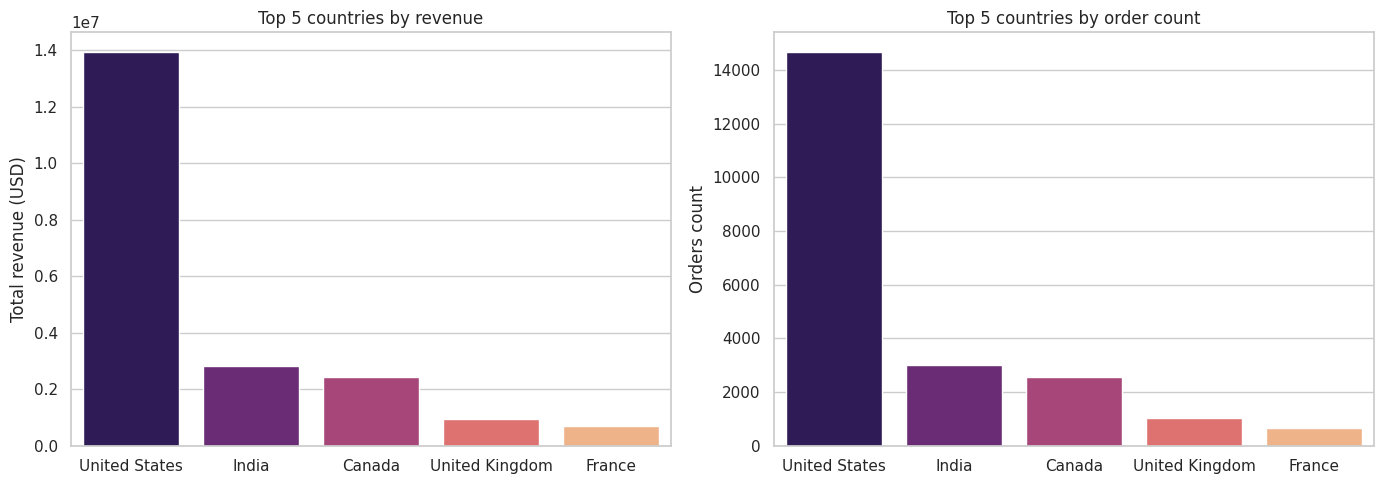

In [8]:
purchases = df[df["product_name"].notna()].copy()

# Top continents by revenue and order count
top_continents = (
    purchases.groupby("continent")
    .agg(total_revenue=("product_price", "sum"), orders_count=("product_name", "count"))
    .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=top_continents.head(3).reset_index(), x="continent", y="total_revenue",
            hue="continent", legend=False, palette="viridis", ax=axes[0])
axes[0].set_title("Top 3 continents by revenue")
axes[0].set_ylabel("Total revenue (USD)")
axes[0].set_xlabel("")

sns.barplot(data=top_continents.head(3).reset_index(), x="continent", y="orders_count",
            hue="continent", legend=False, palette="viridis", ax=axes[1])
axes[1].set_title("Top 3 continents by order count")
axes[1].set_ylabel("Orders count")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

# Top countries by revenue and order count
top_countries = (
    purchases.groupby("country")
    .agg(total_revenue=("product_price", "sum"), orders_count=("product_name", "count"))
    .sort_values("total_revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top_countries.head(5).reset_index(), x="country", y="total_revenue",
            hue="country", legend=False, palette="magma", ax=axes[0])
axes[0].set_title("Top 5 countries by revenue")
axes[0].set_ylabel("Total revenue (USD)")
axes[0].set_xlabel("")

sns.barplot(data=top_countries.head(5).reset_index(), x="country", y="orders_count",
            hue="country", legend=False, palette="magma", ax=axes[1])
axes[1].set_title("Top 5 countries by order count")
axes[1].set_ylabel("Orders count")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

EN: The Americas is the clear leader in sales (≈17.5M USD, ≈18,500 orders), nearly doubling Asia and Europe, which show similar results to each other (≈0.6-0.75M USD). At the country level, the United States dominates with ≈14M USD (far exceeding all other top-4 countries combined) and ≈14,600 orders. India and Canada rank second and third with roughly similar figures (≈0.25-0.3M USD), while the UK and France trail significantly behind. Revenue and order-count rankings match exactly for both continents and countries, suggesting the average order value is fairly consistent across regions, and the sales gap comes from order volume rather than price differences.

                   product_category  total_revenue  orders_count
0                 Sofas & armchairs      8388254.5          4301
1                            Chairs      6147748.8          5952
2                              Beds      4919725.0          2926
3        Bookcases & shelving units      3640818.1          7630
4              Cabinets & cupboards      2336499.5          2318
5                 Outdoor furniture      2142222.2          2229
6                    Tables & desks      1790307.5          2941
7  Chests of drawers & drawer units       906562.5          1452
8                     Bar furniture       735503.0          1092
9              Children's furniture       467697.0          1702


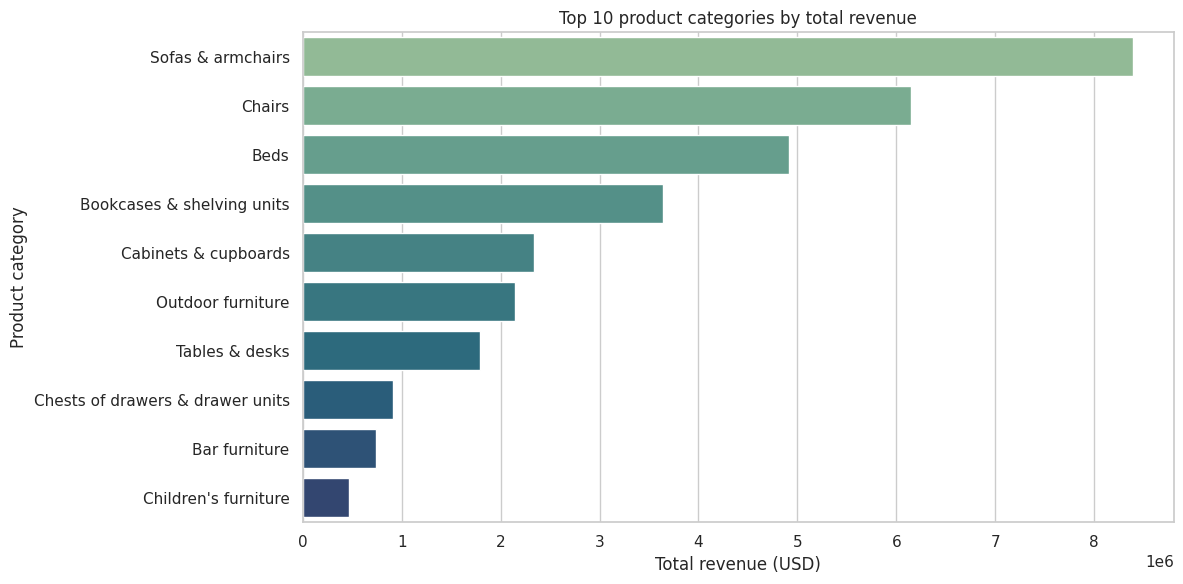

In [9]:
top_categories = (
    purchases.groupby("product_category")
    .agg(total_revenue=("product_price", "sum"), orders_count=("product_name", "count"))
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)
print(top_categories)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x="total_revenue", y="product_category",
            hue="product_category", legend=False, palette="crest")
plt.title("Top 10 product categories by total revenue")
plt.xlabel("Total revenue (USD)")
plt.ylabel("Product category")
plt.tight_layout()
plt.show()

The category generating the highest revenue is Sofas & armchairs (≈8.39M USD), even though it has fewer orders (4,301) than several other categories — explained by its high average price (≈1,950 USD per order). Chairs ranks second (≈6.15M USD, 5,952 orders), and Beds third (≈4.92M USD). Interestingly, Bookcases & shelving units has the highest order count among the top 4 categories (7,630), but due to its low average price (≈477 USD) it generates noticeably less revenue (≈3.64M USD). This shows that the revenue ranking doesn't always match the popularity ranking — some categories drive sales through high price points rather than order volume.

Country with highest sales: United States
                   product_category  total_revenue  orders_count
0                 Sofas & armchairs      3707144.5          1903
1                            Chairs      2619773.8          2576
2                              Beds      2213058.0          1298
3        Bookcases & shelving units      1567606.9          3374
4              Cabinets & cupboards       994545.5           995
5                 Outdoor furniture       929245.2           984
6                    Tables & desks       777865.0          1248
7  Chests of drawers & drawer units       382388.0           616
8                     Bar furniture       330805.0           487
9              Children's furniture       207575.0           752


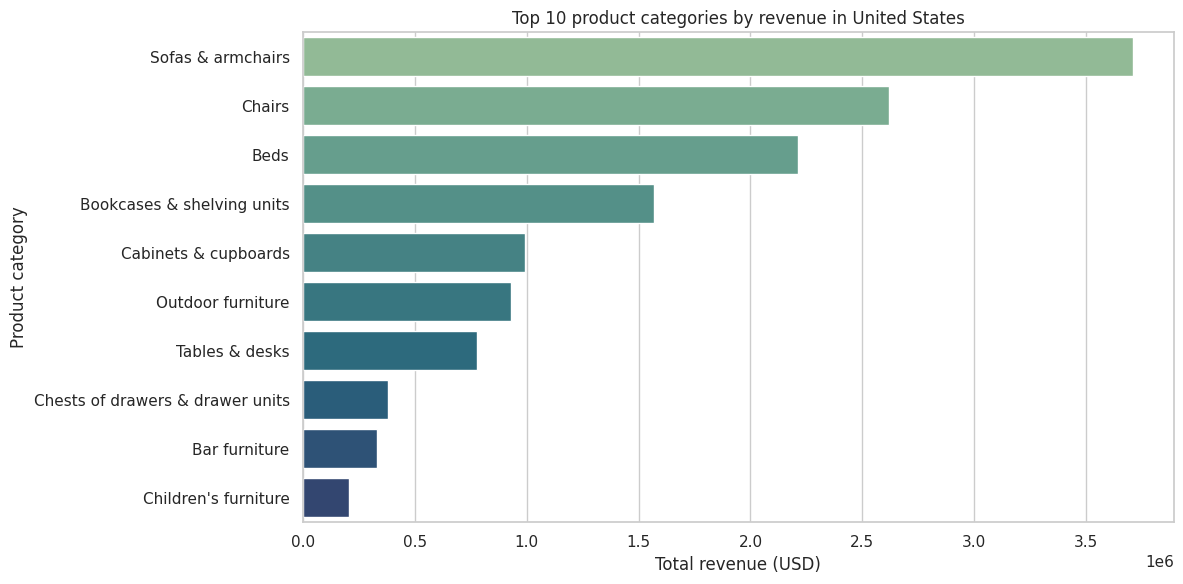


Overall top 10 categories:
 ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]

Top 10 categories in United States:
 ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]


In [10]:
top_country_name = top_countries.index[0]
print("Country with highest sales:", top_country_name)

top_categories_in_top_country = (
    purchases[purchases["country"] == top_country_name]
    .groupby("product_category")
    .agg(total_revenue=("product_price", "sum"), orders_count=("product_name", "count"))
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)
print(top_categories_in_top_country)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories_in_top_country, x="total_revenue", y="product_category",
            hue="product_category", legend=False, palette="crest")
plt.title(f"Top 10 product categories by revenue in {top_country_name}")
plt.xlabel("Total revenue (USD)")
plt.ylabel("Product category")
plt.tight_layout()
plt.show()

# Compare rankings
print("\nOverall top 10 categories:\n", top_categories["product_category"].tolist())
print(f"\nTop 10 categories in {top_country_name}:\n", top_categories_in_top_country["product_category"].tolist())

The top-10 category ranking in the United States matches the global ranking exactly — both in composition and order: Sofas & armchairs (≈3.71M USD) remains the leader, followed by Chairs (≈2.62M USD) and Beds (≈2.21M USD), down to Children's furniture in 10th place. This suggests that US buying preferences mirror the global sales pattern — the US likely dominates the Americas' volume so heavily (≈78% of the continent's revenue) that it effectively drives the overall trend rather than just following it. No local deviations in demand structure were found.

    device  revenue_share_pct
0  desktop              59.00
1   mobile              38.73
2   tablet               2.26


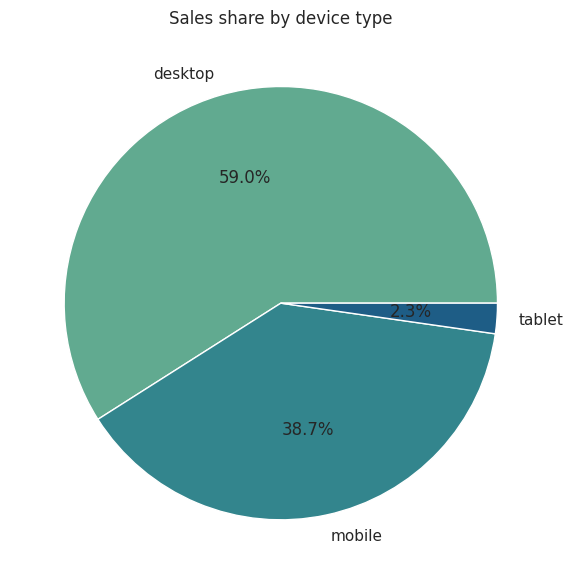

  mobile_model_name  revenue_share_pct
0            Chrome              27.84
1           <Other>              20.44
2            Safari              20.30
3            iPhone              20.08
4        ChromeBook               5.73
5              Edge               2.18
6              iPad               1.40
7           Firefox               1.32
8        Pixel 4 XL               0.37
9           Pixel 3               0.34


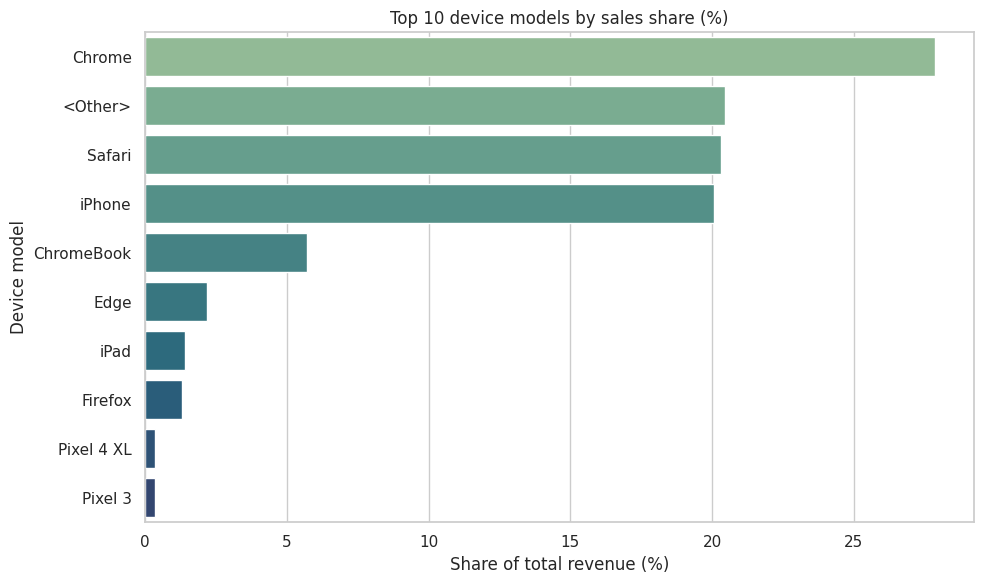

In [11]:
device_sales = (
    purchases.groupby("device")["product_price"].sum()
    .sort_values(ascending=False)
)
device_sales_pct = (device_sales / device_sales.sum() * 100).round(2).reset_index()
device_sales_pct.columns = ["device", "revenue_share_pct"]
print(device_sales_pct)

plt.figure(figsize=(8, 6))
plt.pie(device_sales_pct["revenue_share_pct"], labels=device_sales_pct["device"],
        autopct="%1.1f%%", colors=sns.color_palette("crest", len(device_sales_pct)))
plt.title("Sales share by device type")
plt.tight_layout()
plt.show()

model_sales = (
    purchases.groupby("mobile_model_name")["product_price"].sum()
    .sort_values(ascending=False)
    .head(10)
)
model_sales_pct = (model_sales / purchases["product_price"].sum() * 100).round(2).reset_index()
model_sales_pct.columns = ["mobile_model_name", "revenue_share_pct"]
print(model_sales_pct)

plt.figure(figsize=(10, 6))
sns.barplot(data=model_sales_pct, x="revenue_share_pct", y="mobile_model_name",
            hue="mobile_model_name", legend=False, palette="crest")
plt.title("Top 10 device models by sales share (%)")
plt.xlabel("Share of total revenue (%)")
plt.ylabel("Device model")
plt.tight_layout()
plt.show()

By device type, desktop dominates with 59.0% of sales, followed by mobile at 38.7%, and tablet at only 2.3%. This suggests that despite the general trend toward mobile commerce, most purchases on this site still happen via computer — likely because furniture is a large, considered purchase that's easier to make on a bigger screen.


Regarding device models (mobile_model_name) — there's a data quality issue here: the top-10 list mixes browser names (Chrome, Safari, Edge, Firefox) with actual device names (iPhone, ChromeBook, iPad, Pixel 4 XL, Pixel 3). This suggests the mobile_model_name field is likely populated with the browser name for desktop sessions, while showing the real phone model for mobile sessions. So a direct "model" comparison is misleading here: Chrome (27.8%) isn't actually a device model — it's effectively the primary browser of desktop users. The most popular real mobile model is iPhone (20.1%), with no Android model appearing in the top ranks besides a small Pixel share (0.37% + 0.34%).

   traffic_source  revenue_share_pct
0         organic              34.20
1          (none)              23.44
2        referral              17.65
3         <Other>              14.05
4  (data deleted)               6.39
5             cpc               4.27


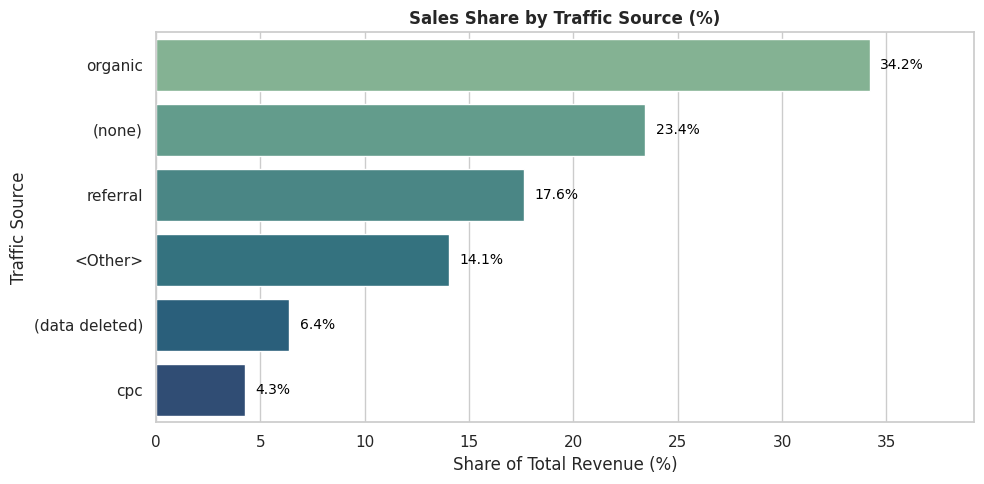

  traffic_channel  revenue_share_pct
0  Organic Search              35.76
1     Paid Search              26.62
2          Direct              23.44
3   Social Search               7.92
4       Undefined               6.26


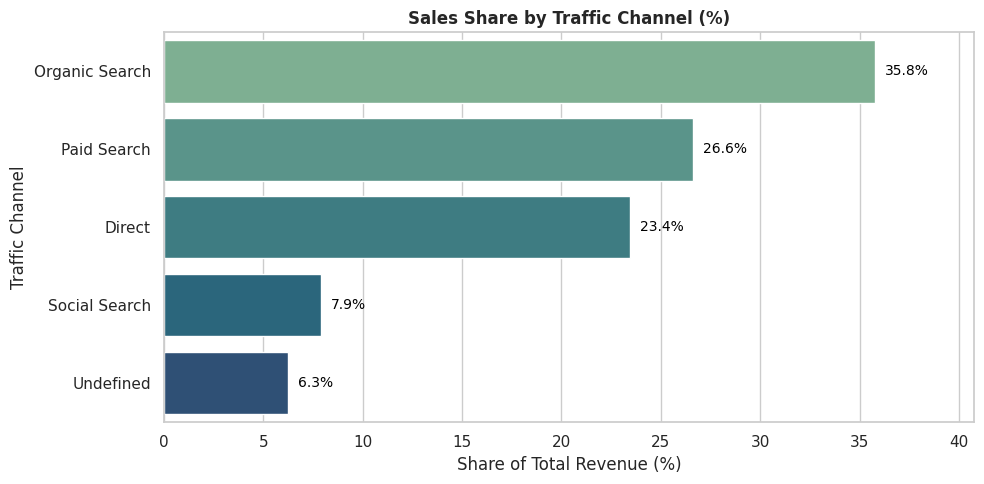

In [43]:
traffic_sales = (
    purchases.groupby("traffic_source")["product_price"].sum()
    .sort_values(ascending=False)
)
traffic_sales_pct = (traffic_sales / traffic_sales.sum() * 100).round(2).reset_index()
traffic_sales_pct.columns = ["traffic_source", "revenue_share_pct"]
print(traffic_sales_pct)

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(
    data=traffic_sales_pct,
    x="revenue_share_pct",
    y="traffic_source",
    hue="traffic_source",
    legend=False,
    palette="crest"
)

for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(
        f'{width:.1f}%',
        (width + 0.5, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Sales Share by Traffic Source (%)", fontsize=12, fontweight='bold')
plt.xlabel("Share of Total Revenue (%)")
plt.ylabel("Traffic Source")
plt.xlim(0, traffic_sales_pct["revenue_share_pct"].max() + 5)
plt.tight_layout()
plt.show()


channel_sales = (
    purchases.groupby("traffic_channel")["product_price"].sum()
    .sort_values(ascending=False)
)
channel_sales_pct = (channel_sales / channel_sales.sum() * 100).round(2).reset_index()
channel_sales_pct.columns = ["traffic_channel", "revenue_share_pct"]
print(channel_sales_pct)

plt.figure(figsize=(10, 5))
ax2 = sns.barplot(
    data=channel_sales_pct,
    x="revenue_share_pct",
    y="traffic_channel",
    hue="traffic_channel",
    legend=False,
    palette="crest"
)

for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(
        f'{width:.1f}%',
        (width + 0.5, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Sales Share by Traffic Channel (%)", fontsize=12, fontweight='bold')
plt.xlabel("Share of Total Revenue (%)")
plt.ylabel("Traffic Channel")
plt.xlim(0, channel_sales_pct["revenue_share_pct"].max() + 5)
plt.tight_layout()
plt.show()

By traffic source, organic leads (34.2%), followed by (none) (23.4%, direct visits with no source) and referral (17.7%). By traffic channel (the aggregated classification), the picture shifts slightly: Organic Search (35.8%) and Paid Search (26.6%) together account for over 60% of sales, meaning search is the main driver of both traffic and revenue. Direct (23.4%) is also significant, while Social Search (7.9%) and Undefined (6.3%) are minor. This suggests investment should focus on SEO and paid search, since social media currently contributes little to sales.

Total registered users: 27945
    is_verified  count
0      Verified  20036
1  Not verified   7909

Verified email share: 71.7%


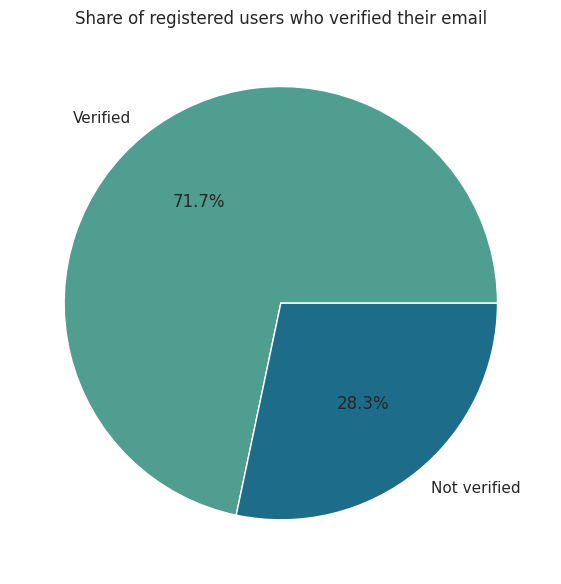

In [14]:
registered_users = df[df["account_id"].notna()].drop_duplicates(subset="account_id")

verified_counts = registered_users["is_verified"].value_counts().reset_index()
verified_counts.columns = ["is_verified", "count"]
verified_counts["is_verified"] = verified_counts["is_verified"].map({1: "Verified", 0: "Not verified"})

verified_pct = (registered_users["is_verified"].sum() / len(registered_users) * 100).round(2)

print("Total registered users:", len(registered_users))
print(verified_counts)
print(f"\nVerified email share: {verified_pct}%")

plt.figure(figsize=(6, 6))
plt.pie(verified_counts["count"], labels=verified_counts["is_verified"],
        autopct="%1.1f%%", colors=sns.color_palette("crest", 2))
plt.title("Share of registered users who verified their email")
plt.tight_layout()
plt.show()

Out of 27,945 registered users, 71.7% (20,036) verified their email address, while 28.3% (7,909) remained unverified. This is a fairly high verification rate — most people who leave an email actually complete the verification process, indicating a reasonably good UX for the registration form and no major technical barriers in the confirmation flow.

Total registered users: 27945
  is_unsubscribed  count
0      Subscribed  23210
1    Unsubscribed   4735

Unsubscribed share: 16.94%


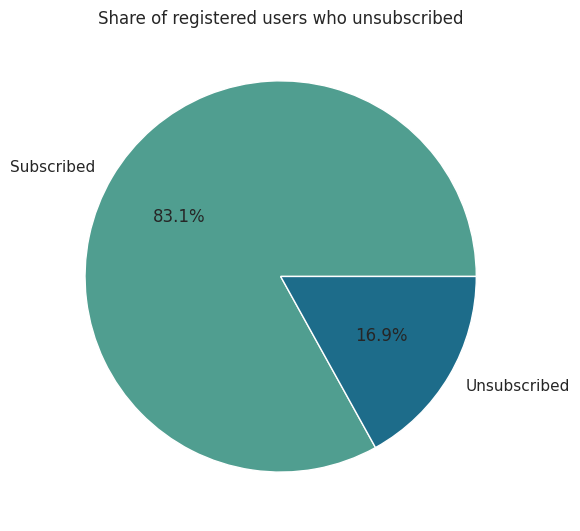

In [15]:
unsubscribed_counts = registered_users["is_unsubscribed"].value_counts().reset_index()
unsubscribed_counts.columns = ["is_unsubscribed", "count"]
unsubscribed_counts["is_unsubscribed"] = unsubscribed_counts["is_unsubscribed"].map(
    {1: "Unsubscribed", 0: "Subscribed"}
)

unsubscribed_pct = (registered_users["is_unsubscribed"].sum() / len(registered_users) * 100).round(2)

print("Total registered users:", len(registered_users))
print(unsubscribed_counts)
print(f"\nUnsubscribed share: {unsubscribed_pct}%")

plt.figure(figsize=(6, 6))
plt.pie(unsubscribed_counts["count"], labels=unsubscribed_counts["is_unsubscribed"],
        autopct="%1.1f%%", colors=sns.color_palette("crest", 2))
plt.title("Share of registered users who unsubscribed")
plt.tight_layout()
plt.show()

Out of 27,945 registered users, 83.1% (23,210) remain subscribed to the newsletter, and only 16.9% (4,735) unsubscribed. This is a relatively low unsubscribe rate — most users who register don't mind receiving regular emails, suggesting the newsletter's frequency and content relevance are reasonably well-tuned for most of the audience.

  subscription_status  orders_count  total_revenue  avg_order_value
0          Subscribed          2334      2150796.9           921.51
1        Unsubscribed           447       431721.6           965.82


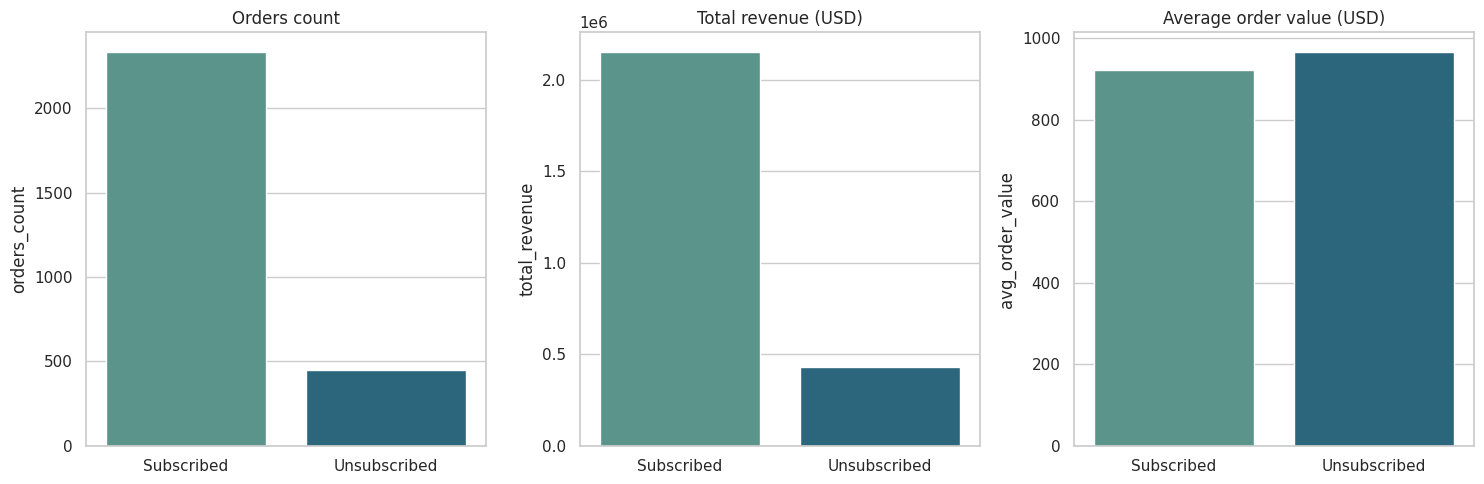

In [16]:
# Take purchases made by registered users only, and attach subscription status
purchases_registered = purchases[purchases["account_id"].notna()].copy()
purchases_registered["subscription_status"] = purchases_registered["is_unsubscribed"].map(
    {1: "Unsubscribed", 0: "Subscribed"}
)

subscription_comparison = (
    purchases_registered.groupby("subscription_status")
    .agg(
        orders_count=("product_name", "count"),
        total_revenue=("product_price", "sum"),
        avg_order_value=("product_price", "mean"),
    )
    .round(2)
    .reset_index()
)
print(subscription_comparison)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=subscription_comparison, x="subscription_status", y="orders_count",
            hue="subscription_status", legend=False, palette="crest", ax=axes[0])
axes[0].set_title("Orders count")
axes[0].set_xlabel("")

sns.barplot(data=subscription_comparison, x="subscription_status", y="total_revenue",
            hue="subscription_status", legend=False, palette="crest", ax=axes[1])
axes[1].set_title("Total revenue (USD)")
axes[1].set_xlabel("")

sns.barplot(data=subscription_comparison, x="subscription_status", y="avg_order_value",
            hue="subscription_status", legend=False, palette="crest", ax=axes[2])
axes[2].set_title("Average order value (USD)")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

In absolute numbers, subscribed users generate far more orders (2,334 vs 447) and revenue (≈2.15M USD vs ≈432K USD), but this is expected since there are 4.9x more subscribed users than unsubscribed ones (23,210 vs 4,735). The most interesting metric is the average order value: unsubscribed users actually have a slightly higher one (≈965.82 USD vs ≈921.51 USD for subscribed). This suggests that unsubscribing is not linked to reduced purchasing power or willingness to spend — unsubscribed users spend, on average, slightly more per order. The unsubscribe decision is likely driven by email fatigue or a preference to avoid marketing messages, rather than a loss of interest in the product itself.

          country  registered_users_count
0   United States                   12384
1           India                    2687
2          Canada                    2067
3  United Kingdom                     859
4          France                     553
5           Spain                     536
6          Taiwan                     500
7           China                     490
8         Germany                     490
9           Italy                     386


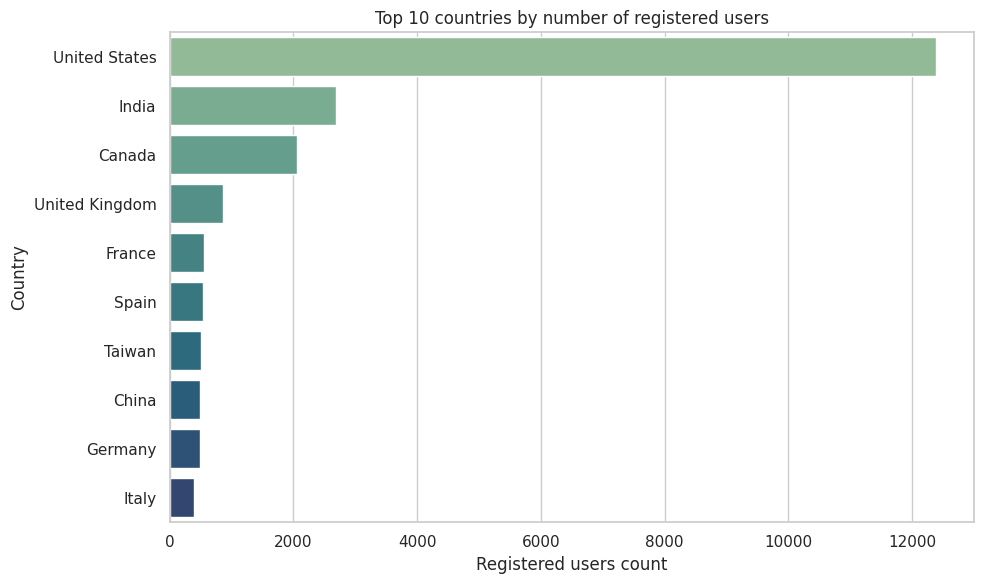

In [17]:
top_countries_registered = (
    registered_users.groupby("country")["account_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_countries_registered.columns = ["country", "registered_users_count"]
print(top_countries_registered)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_countries_registered, x="registered_users_count", y="country",
            hue="country", legend=False, palette="crest")
plt.title("Top 10 countries by number of registered users")
plt.xlabel("Registered users count")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

The United States dominates in registered users — 12,384, almost 4.6 times more than the second-ranked India (2,687). Canada is third with 2,067 users. There's a sharp drop after that: UK (859), France (553), Spain (536) — all other top-10 countries have fewer than 900 registrations. This ranking almost exactly matches the top-5 sales countries from Item 1 (US, India, Canada, UK, France) — which makes sense, since a larger registered user base typically means a more active, engaged audience that also drives sales.

           browser  orders_count  total_revenue
0           Chrome         23015     21826850.0
1           Safari          7903      7526544.0
2          <Other>           865       923354.8
3             Edge           752       716444.3
4          Firefox           583       567523.6
5  Android Webview           420       411014.4


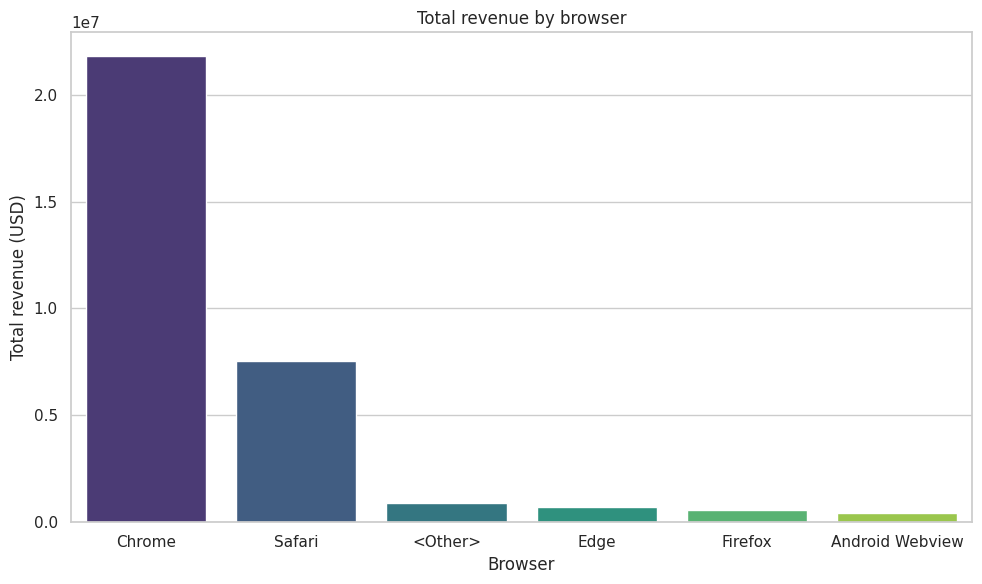

In [18]:
browser_sales = (
    purchases.groupby("browser")
    .agg(orders_count=("product_name", "count"), total_revenue=("product_price", "sum"))
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)
print(browser_sales)

plt.figure(figsize=(10, 6))
sns.barplot(data=browser_sales, x="browser", y="total_revenue",
            hue="browser", legend=False, palette="viridis")
plt.title("Total revenue by browser")
plt.xlabel("Browser")
plt.ylabel("Total revenue (USD)")
plt.tight_layout()
plt.show()

Chrome dominates unambiguously, generating ≈21.8M USD in revenue (23,015 orders) — almost three times more than Safari, which ranks second with ≈7.5M USD (7,903 orders). All other browsers (Edge, Firefox, Android Webview, Other) together account for less than 1% of total revenue and are barely visible on the chart. This aligns with Chrome's overall global popularity as a browser and is consistent with the earlier finding that desktop dominates (59%) — Chrome is traditionally most popular on desktop. Practically speaking, site optimization should prioritize Chrome and Safari, since together they cover over 95% of sales.

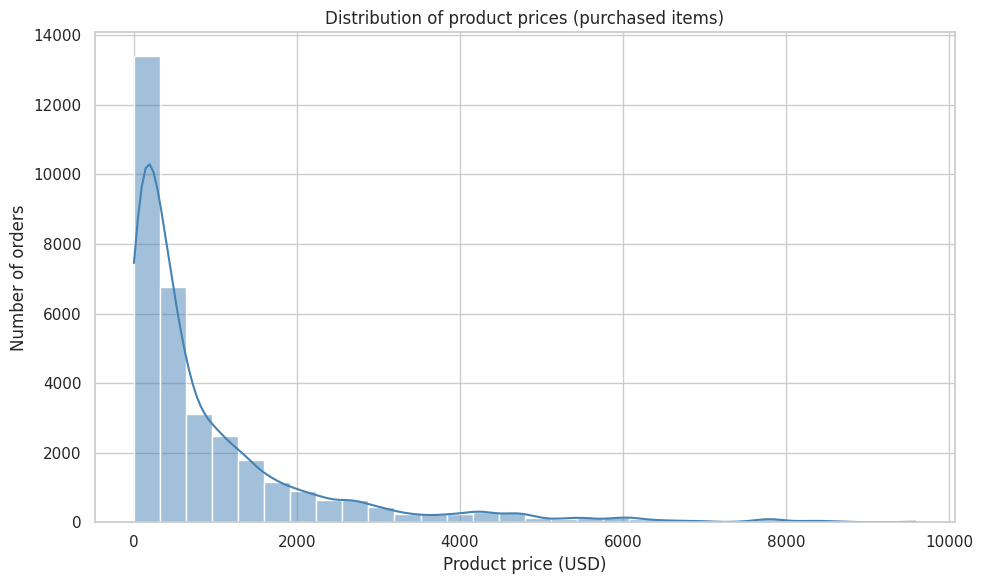

count    33538.000000
mean       953.298679
std       1317.001775
min          3.000000
25%        170.000000
50%        445.000000
75%       1195.000000
max       9585.000000
Name: product_price, dtype: float64


In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=purchases, x="product_price", bins=30, kde=True, color="steelblue")
plt.title("Distribution of product prices (purchased items)")
plt.xlabel("Product price (USD)")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()

print(purchases["product_price"].describe())

The price distribution shows a clear right skew — the vast majority of orders fall in the 0-1,500 USD range, with a sharp peak in the 0-500 USD bucket (≈13,400 orders). The median (445 USD) is significantly lower than the mean (953.30 USD) — a classic sign that a small number of expensive items (up to 9,585 USD) pull the average upward, while a typical purchase costs much less. The interquartile range (25%-75%) spans from 170 to 1,195 USD, meaning half of all orders fall within this price band. This distribution is typical for a furniture store: many affordable accessories/small items combined with a small number of premium pieces (large sofas, cabinets) create a long tail of high prices.

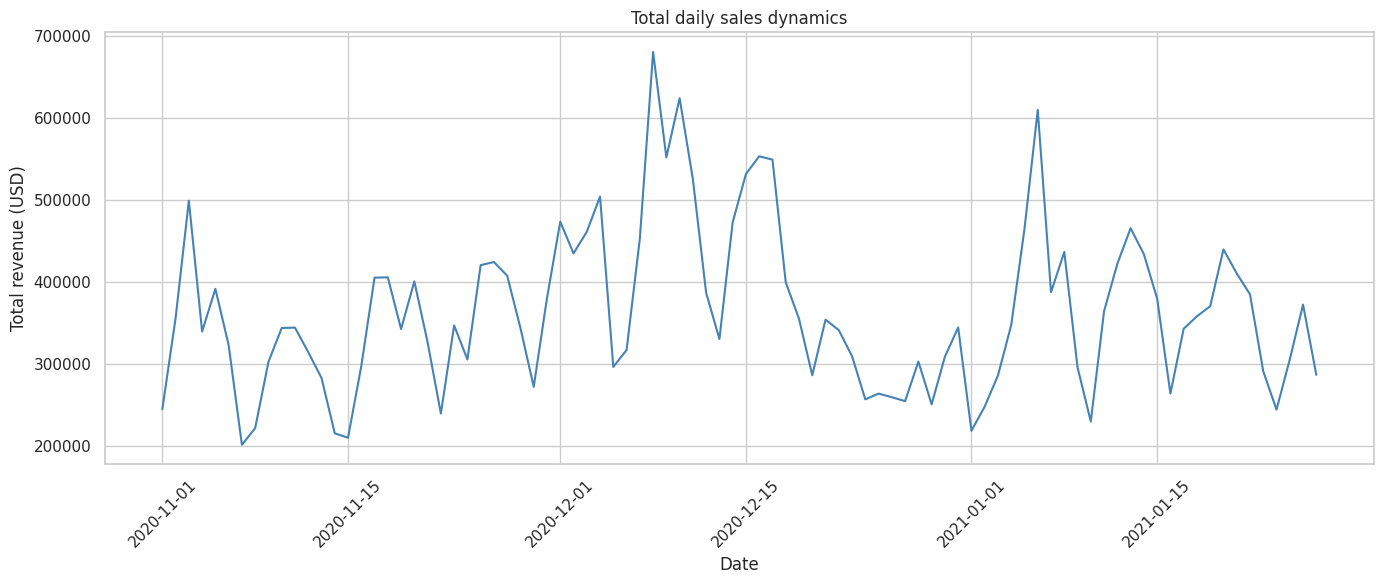

       total_revenue
count      88.000000
mean   363315.126136
std    100327.343244
min    200892.200000
25%    294144.675000
50%    345354.000000
75%    420636.575000
max    680509.500000


In [21]:
daily_sales = (
    purchases.groupby("session_date")["product_price"].sum()
    .reset_index()
    .rename(columns={"product_price": "total_revenue"})
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x="session_date", y="total_revenue", color="steelblue")
plt.title("Total daily sales dynamics")
plt.xlabel("Date")
plt.ylabel("Total revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(daily_sales.describe())

Sales show clear weekly seasonality — regular zigzag fluctuations (rises and drops) repeat roughly every 7 days, which is typical for e-commerce (different activity levels on weekdays vs weekends). Beyond that, there are two distinct seasonal peaks: the first in early December (≈680,509 USD, the highest value in the entire period), likely tied to pre-holiday sales / Black Friday-Cyber Monday season; the second in early January (≈610,000 USD), which may correspond to holiday gift purchases or post-holiday sale promotions. The lowest sales values (≈200,000-220,000 USD) occur in mid-November and early January — likely "lulls" between seasonal waves. On average, daily sales are ≈363,315 USD, with notable variability (std ≈100,327 USD, about 28% of the mean) — confirming unstable demand and pronounced seasonality rather than a steady order flow.

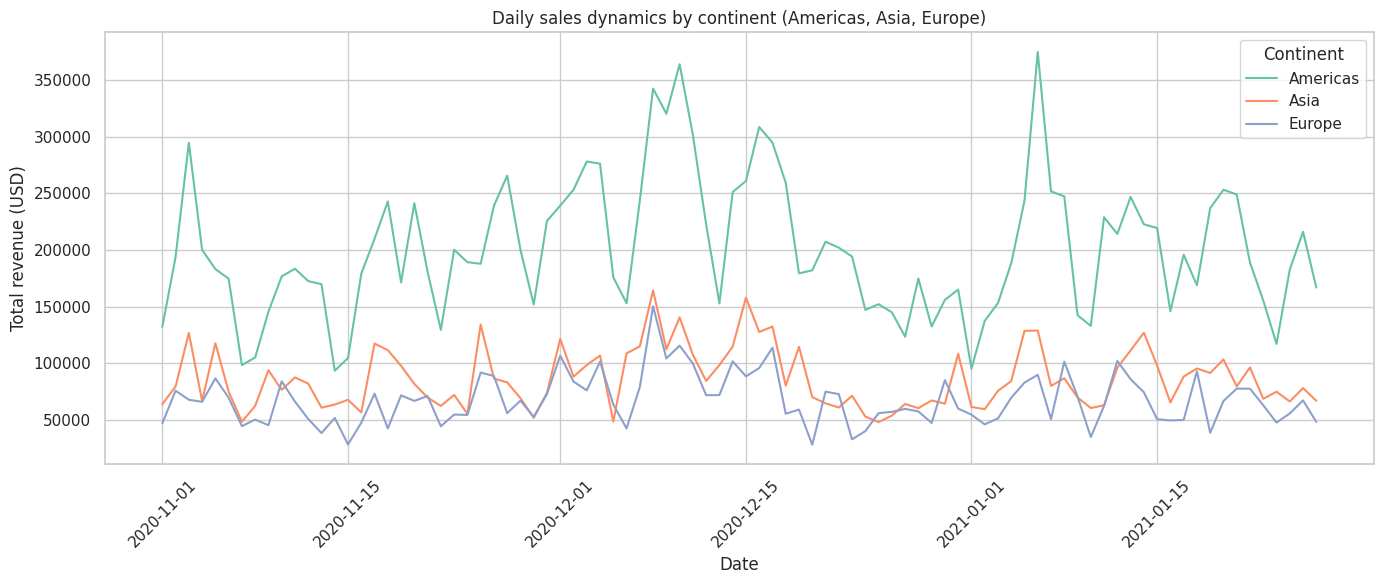

In [22]:
continent_daily = (
    purchases[purchases["continent"].isin(["Americas", "Asia", "Europe"])]
    .groupby(["session_date", "continent"])["product_price"]
    .sum()
    .reset_index()
    .rename(columns={"product_price": "total_revenue"})
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=continent_daily, x="session_date", y="total_revenue",
             hue="continent", palette="Set2")
plt.title("Daily sales dynamics by continent (Americas, Asia, Europe)")
plt.xlabel("Date")
plt.ylabel("Total revenue (USD)")
plt.xticks(rotation=45)
plt.legend(title="Continent")
plt.tight_layout()
plt.show()

The Americas consistently and substantially outpaces the other continents throughout the entire period — consistent with the findings from Item 1. Weekly seasonality (zigzag fluctuations) is clearly visible across all three lines, and peaks align by date across continents simultaneously (e.g., the shared spike in early December and early January) — meaning seasonal factors (Black Friday, holiday sales) drive demand globally, not in a region-specific way. Interestingly, Asia and Europe show very similar dynamics and amplitude for most of the period, often overlapping on the chart, with Europe briefly overtaking Asia in mid-December (spike to ≈150,000 USD), possibly due to European Christmas shopping preceding the Asian New Year. Overall, no continent shows a fundamentally independent behavior pattern — all three markets move in sync, just at different scales.

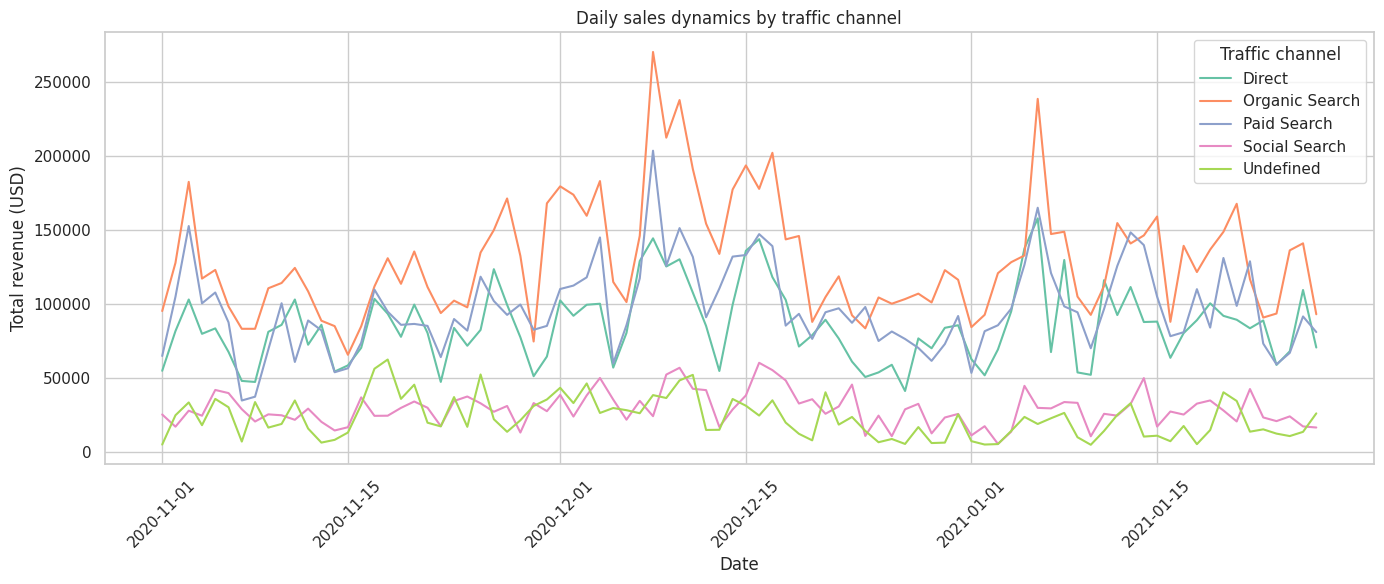

In [23]:
channel_daily = (
    purchases.groupby(["session_date", "traffic_channel"])["product_price"]
    .sum()
    .reset_index()
    .rename(columns={"product_price": "total_revenue"})
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=channel_daily, x="session_date", y="total_revenue",
             hue="traffic_channel", palette="Set2")
plt.title("Daily sales dynamics by traffic channel")
plt.xlabel("Date")
plt.ylabel("Total revenue (USD)")
plt.xticks(rotation=45)
plt.legend(title="Traffic channel")
plt.tight_layout()
plt.show()

Organic Search (orange line) consistently leads for nearly the entire period, confirming the earlier finding about search traffic dominance. A notable anomaly appears in early December: Paid Search (blue line) spikes sharply and nearly matches Organic Search (both ≈200,000-270,000 USD) — likely coinciding with the December seasonal sales peak, when the company likely ramped up paid advertising (e.g., around Black Friday/Cyber Monday) to capitalize on high demand. Direct and Paid Search show similar amplitude and often track closely together for most of the chart, while Social Search and Undefined remain consistently the lowest channels (rarely exceeding 50,000-60,000 USD) with no clear seasonal spikes — confirming the earlier finding that social media is not yet a significant sales driver for this store.

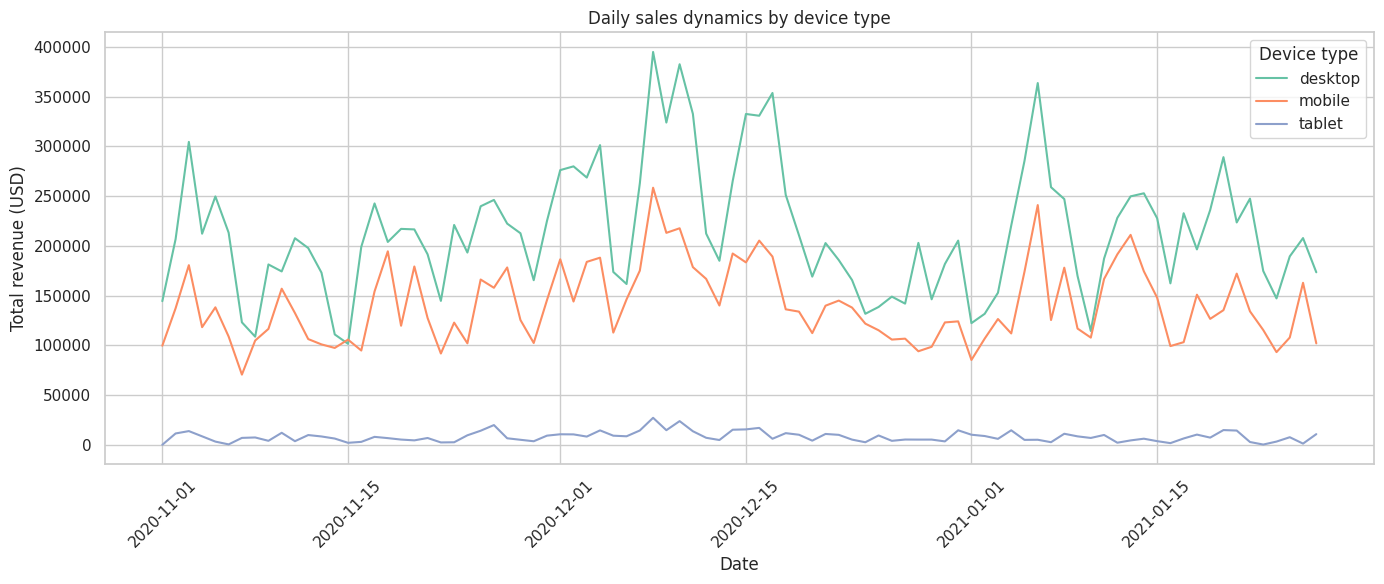

In [24]:
device_daily = (
    purchases.groupby(["session_date", "device"])["product_price"]
    .sum()
    .reset_index()
    .rename(columns={"product_price": "total_revenue"})
)

plt.figure(figsize=(14, 6))
sns.lineplot(data=device_daily, x="session_date", y="total_revenue",
             hue="device", palette="Set2")
plt.title("Daily sales dynamics by device type")
plt.xlabel("Date")
plt.ylabel("Total revenue (USD)")
plt.xticks(rotation=45)
plt.legend(title="Device type")
plt.tight_layout()
plt.show()

Desktop consistently outperforms mobile throughout the entire period, consistent with the overall 59% vs 38.7% split from Item 4. Both channels show synchronized weekly seasonality and identical seasonal peaks (early December, early January) — meaning seasonal factors affect all devices simultaneously rather than being specific to one type. Tablet remains a consistently minor channel (rarely exceeding 20,000-25,000 USD) with no noticeable spikes even on peak days — this segment is fully niche and doesn't respond to overall demand trends as strongly as desktop and mobile. Interestingly, mobile's fluctuation amplitude is relatively higher than desktop's (e.g., during the December peak, mobile nearly triples from its minimum, while desktop roughly doubles) — this may suggest mobile users are more responsive to promotions or impulse purchases during sales events.

In [25]:
pivot_sessions = pd.pivot_table(
    df,
    values="ga_session_id",
    index="traffic_channel",
    columns="device",
    aggfunc="count",
    fill_value=0
)
print(pivot_sessions)

device           desktop  mobile  tablet
traffic_channel                         
Direct             47825   31745    1812
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Social Search      16288   10988     638
Undefined          12527    8486     470


Organic Search generates the highest number of sessions across all device types (72,622 desktop, 49,014 mobile), with desktop holding the largest share of sessions in every channel — consistent with the earlier finding of desktop dominance (59% of sales). Paid Search also shows strong results (55,167 desktop, 37,034 mobile), while Social Search and Undefined have the fewest sessions across all devices, confirming their low significance found earlier in the sales analysis.

In [26]:
top_10_categories = top_categories["product_category"].tolist()
top_5_countries = top_countries.head(5).index.tolist()

pivot_sales = pd.pivot_table(
    purchases[
        purchases["product_category"].isin(top_10_categories) &
        purchases["country"].isin(top_5_countries)
    ],
    values="product_price",
    index="product_category",
    columns="country",
    aggfunc="sum",
    fill_value=0
)
print(pivot_sales.round(2))

country                             Canada    France     India  \
product_category                                                 
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furniture               30264.0   14258.0   39177.0   
Outdoor furniture                 185322.8   40486.4  162289.4   
Sofas & armchairs                 692427.5  187735.0  788430.0   
Tables & desks                    132678.0   42299.0  186157.5   

country                           United Kingdom  United States  
product_category                                                 
Bar furniture                            22103.0       330805.0  
Beds     

Every one of the top-5 countries shows the same category hierarchy as the global ranking — Sofas & armchairs leads everywhere (from 187,735 USD in France to 3,707,144.5 USD in the United States), followed by Chairs and Beds. This confirms the finding from Item 3: demand structure is nearly identical regardless of country, with no country showing a fundamentally different purchasing profile.

In [27]:
pivot_aov = pd.pivot_table(
    purchases,
    values="product_price",
    index="continent",
    columns="device",
    aggfunc="mean",
    fill_value=0
).round(2)
print(pivot_aov)

device     desktop   mobile   tablet
continent                           
(not set)  1032.87  1117.70    70.00
Africa     1030.02   907.48   987.14
Americas    962.17   936.26   966.60
Asia        940.15   971.46  1110.69
Europe      955.43   935.09   978.02
Oceania    1039.48   942.73   847.78


The most interesting observation: in Asia, tablet shows the highest average order value (1,110.69 USD), notably different from other continents where tablet usually performs average or below (e.g., Americas — 966.60 USD, Europe — 978.02 USD). Overall, the average order value across continents and devices ranges from 907-1,117 USD, without extreme differences — meaning despite the sales volume differences between regions (Item 1), the typical order value remains relatively stable worldwide and isn't strongly dependent on device type. The (not set) category shows the highest desktop AOV (1,032.87 USD) among all continents, which may indicate atypical or unusual behavior from users with undetermined geolocation.

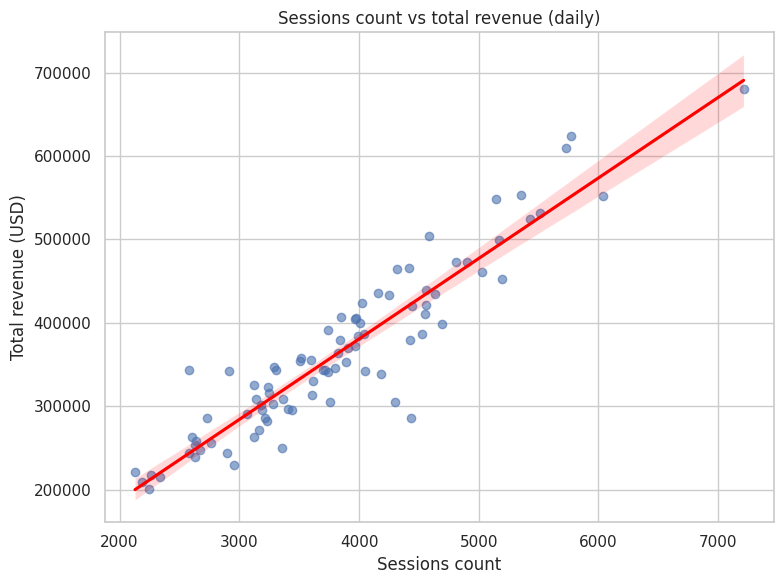

Pearson correlation: 0.931, p-value: 0.00000


In [28]:
from scipy import stats

daily_sessions = df.groupby("session_date")["ga_session_id"].nunique().reset_index()
daily_sessions.columns = ["session_date", "sessions_count"]

daily_combined = daily_sessions.merge(daily_sales, on="session_date")

plt.figure(figsize=(8, 6))
sns.regplot(data=daily_combined, x="sessions_count", y="total_revenue",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Sessions count vs total revenue (daily)")
plt.xlabel("Sessions count")
plt.ylabel("Total revenue (USD)")
plt.tight_layout()
plt.show()

corr, p_value = stats.pearsonr(daily_combined["sessions_count"], daily_combined["total_revenue"])
print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.5f}")

There is a very strong positive correlation (r=0.931, p<0.00001) between daily session count and total revenue — points cluster tightly around the regression line with almost no outliers. This means sales are ≈87% (r²≈0.867) explained simply by traffic volume: more visitors → proportionally more sales. The statistical significance (p-value essentially zero) confirms this relationship isn't random. The most effective lever for revenue growth is driving more traffic (via SEO, paid ads), since conversion remains relatively stable regardless of session volume.

continent  Americas   Asia  Europe
continent                         
Americas      1.000  0.692   0.670
Asia          0.692  1.000   0.668
Europe        0.670  0.668   1.000


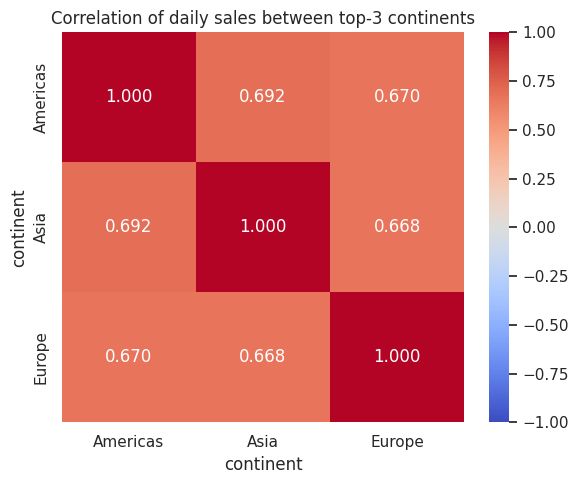

Americas vs Asia: r=0.692, p-value=0.00000
Americas vs Europe: r=0.670, p-value=0.00000
Asia vs Europe: r=0.668, p-value=0.00000


In [30]:
top3_continents = ["Americas", "Asia", "Europe"]

continent_pivot = (
    purchases[purchases["continent"].isin(top3_continents)]
    .groupby(["session_date", "continent"])["product_price"]
    .sum()
    .unstack(fill_value=0)
)

corr_matrix = continent_pivot.corr()
print(corr_matrix.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f")
plt.title("Correlation of daily sales between top-3 continents")
plt.tight_layout()
plt.show()

# Statistical significance for each pair
from itertools import combinations
for c1, c2 in combinations(top3_continents, 2):
    corr, p_value = stats.pearsonr(continent_pivot[c1], continent_pivot[c2])
    print(f"{c1} vs {c2}: r={corr:.3f}, p-value={p_value:.5f}")

All three continent pairs show a moderate positive correlation (Americas-Asia: r=0.692, Americas-Europe: r=0.670, Asia-Europe: r=0.668), and all relationships are statistically significant (p<0.00001). This confirms the visual observation from the earlier chart — seasonal waves (December/January peaks, weekly cyclicality) affect all regions simultaneously, indicating a shared global demand driver rather than independent dynamics per continent.

traffic_channel  Direct  Organic Search  Paid Search  Social Search  Undefined
traffic_channel                                                               
Direct            1.000           0.760        0.724          0.462      0.424
Organic Search    0.760           1.000        0.808          0.434      0.435
Paid Search       0.724           0.808        1.000          0.452      0.430
Social Search     0.462           0.434        0.452          1.000      0.359
Undefined         0.424           0.435        0.430          0.359      1.000


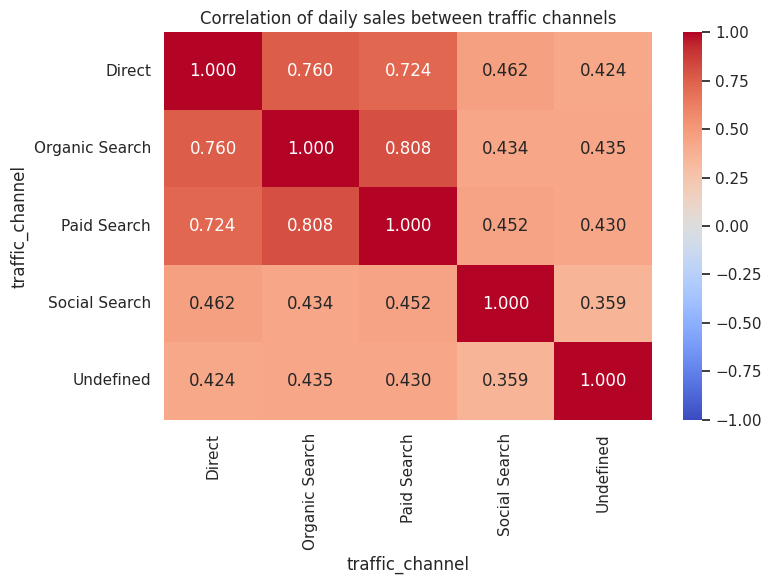

Direct vs Organic Search: r=0.760, p-value=0.00000
Direct vs Paid Search: r=0.724, p-value=0.00000
Direct vs Social Search: r=0.462, p-value=0.00001
Direct vs Undefined: r=0.424, p-value=0.00004
Organic Search vs Paid Search: r=0.808, p-value=0.00000
Organic Search vs Social Search: r=0.434, p-value=0.00002
Organic Search vs Undefined: r=0.435, p-value=0.00002
Paid Search vs Social Search: r=0.452, p-value=0.00001
Paid Search vs Undefined: r=0.430, p-value=0.00003
Social Search vs Undefined: r=0.359, p-value=0.00059


In [31]:
channel_pivot = (
    purchases.groupby(["session_date", "traffic_channel"])["product_price"]
    .sum()
    .unstack(fill_value=0)
)

corr_matrix_channel = channel_pivot.corr()
print(corr_matrix_channel.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_channel, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f")
plt.title("Correlation of daily sales between traffic channels")
plt.tight_layout()
plt.show()

# Statistical significance for each pair
for c1, c2 in combinations(channel_pivot.columns, 2):
    corr, p_value = stats.pearsonr(channel_pivot[c1], channel_pivot[c2])
    print(f"{c1} vs {c2}: r={corr:.3f}, p-value={p_value:.5f}")

The strongest relationship is between Organic Search and Paid Search (r=0.808, p<0.00001), followed by Direct and Organic Search (r=0.760). This makes sense, as all three channels draw from the same overall site traffic pool, which grows during seasonal peaks. Social Search and Undefined show noticeably weaker correlations with all other channels (r≈0.36-0.46) — meaning these channels behave more independently and are less synchronized with overall demand, consistent with their low significance in overall sales. All relationships are statistically significant (p<0.001), though strength varies — the weakest link is Social Search vs Undefined (r=0.359).

product_category             Beds  Bookcases & shelving units  \
product_category                                                
Beds                        1.000                       0.593   
Bookcases & shelving units  0.593                       1.000   
Cabinets & cupboards        0.515                       0.539   
Chairs                      0.554                       0.637   
Sofas & armchairs           0.535                       0.666   

product_category            Cabinets & cupboards  Chairs  Sofas & armchairs  
product_category                                                             
Beds                                       0.515   0.554              0.535  
Bookcases & shelving units                 0.539   0.637              0.666  
Cabinets & cupboards                       1.000   0.573              0.658  
Chairs                                     0.573   1.000              0.578  
Sofas & armchairs                          0.658   0.578              1.000 

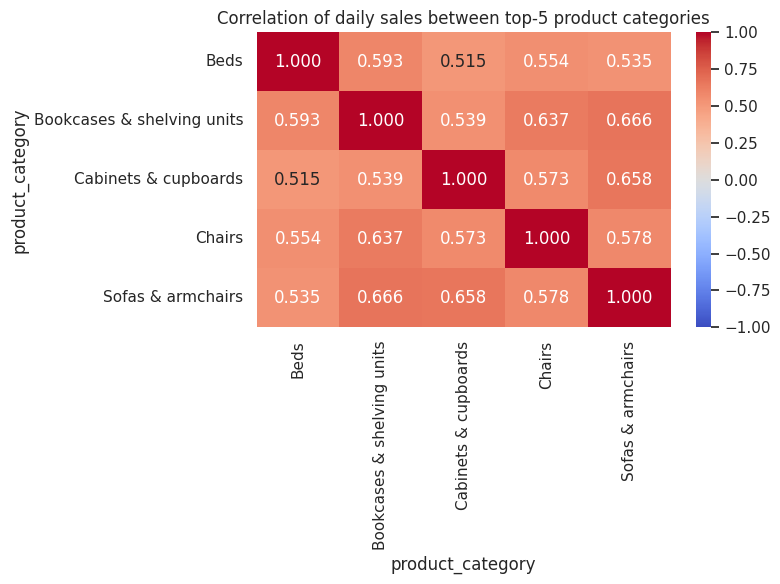

Beds vs Bookcases & shelving units: r=0.593, p-value=0.00000
Beds vs Cabinets & cupboards: r=0.515, p-value=0.00000
Beds vs Chairs: r=0.554, p-value=0.00000
Beds vs Sofas & armchairs: r=0.535, p-value=0.00000
Bookcases & shelving units vs Cabinets & cupboards: r=0.539, p-value=0.00000
Bookcases & shelving units vs Chairs: r=0.637, p-value=0.00000
Bookcases & shelving units vs Sofas & armchairs: r=0.666, p-value=0.00000
Cabinets & cupboards vs Chairs: r=0.573, p-value=0.00000
Cabinets & cupboards vs Sofas & armchairs: r=0.658, p-value=0.00000
Chairs vs Sofas & armchairs: r=0.578, p-value=0.00000


In [32]:
top5_categories = top_categories["product_category"].head(5).tolist()

category_pivot = (
    purchases[purchases["product_category"].isin(top5_categories)]
    .groupby(["session_date", "product_category"])["product_price"]
    .sum()
    .unstack(fill_value=0)
)

corr_matrix_category = category_pivot.corr()
print(corr_matrix_category.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_category, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f")
plt.title("Correlation of daily sales between top-5 product categories")
plt.tight_layout()
plt.show()

# Statistical significance for each pair
for c1, c2 in combinations(category_pivot.columns, 2):
    corr, p_value = stats.pearsonr(category_pivot[c1], category_pivot[c2])
    print(f"{c1} vs {c2}: r={corr:.3f}, p-value={p_value:.5f}")

All category pairs show a moderate positive correlation (range r=0.515-0.666), with no extremely strong or weak relationships. The strongest link is between Bookcases & shelving units and Sofas & armchairs (r=0.666), the weakest is Beds and Cabinets & cupboards (r=0.515). This confirms the earlier finding from Item 5: sales across all categories move in sync due to the same seasonal waves (December/January peaks, weekly cyclicality), but aren't identical — each category also has its own, partially independent demand dynamics. All correlations are statistically significant (p<0.00001).

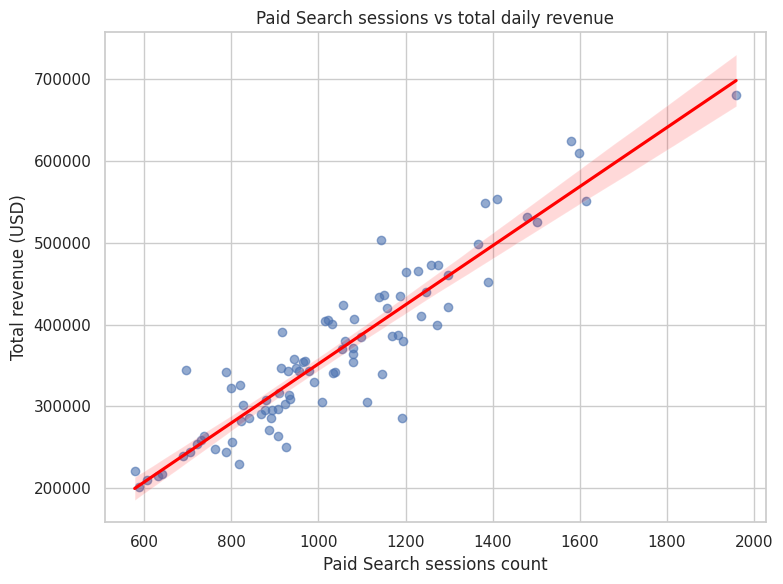

Pearson correlation: 0.924, p-value: 0.00000


In [33]:
paid_search_sessions = (
    df[df["traffic_channel"] == "Paid Search"]
    .groupby("session_date")["ga_session_id"]
    .nunique()
    .reset_index()
)
paid_search_sessions.columns = ["session_date", "paid_search_sessions"]

paid_vs_revenue = paid_search_sessions.merge(daily_sales, on="session_date")

plt.figure(figsize=(8, 6))
sns.regplot(data=paid_vs_revenue, x="paid_search_sessions", y="total_revenue",
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title("Paid Search sessions vs total daily revenue")
plt.xlabel("Paid Search sessions count")
plt.ylabel("Total revenue (USD)")
plt.tight_layout()
plt.show()

corr, p_value = stats.pearsonr(paid_vs_revenue["paid_search_sessions"], paid_vs_revenue["total_revenue"])
print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.5f}")

Paid Search session count shows a very strong correlation with total daily revenue (r=0.924, p<0.00001) — almost as strong as the correlation with total sessions across all channels (r=0.931 from the first item). This confirms what we saw earlier on the chart: the December Paid Search spike aligns with the sales increase not by chance, but consistently. The company likely increases its ad budget during periods of high demand (e.g., around the holidays), so the effect of paid advertising overlaps with the natural seasonal sales growth.

Registered — mean: 29346.8 std: 10765.45
Not registered — mean: 333968.32 std: 92910.21


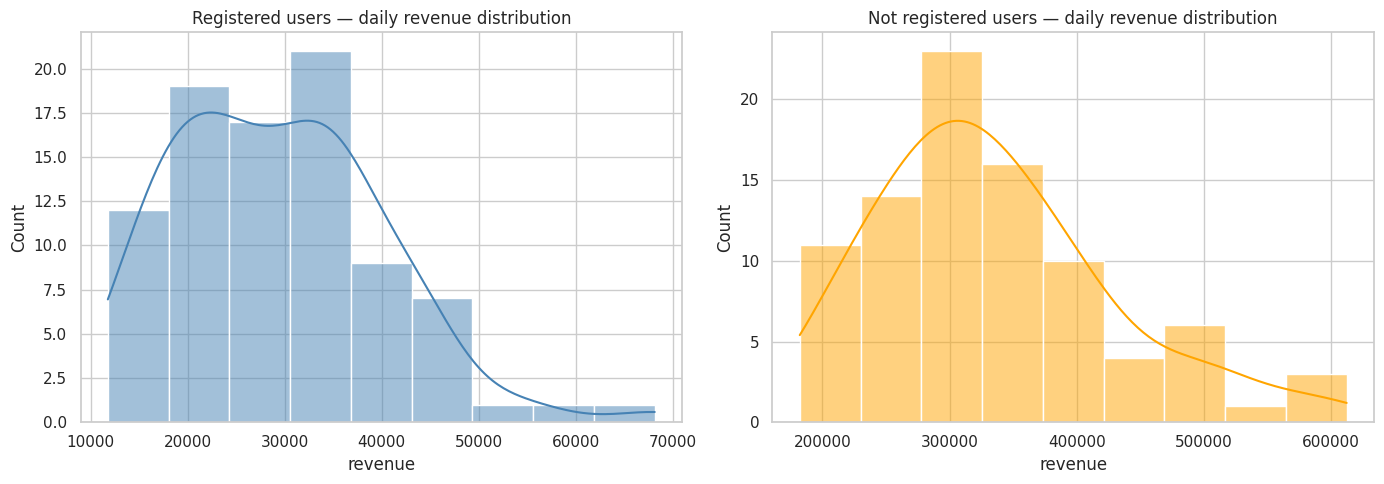


Shapiro-Wilk test (Registered): statistic=0.959, p-value=0.00730
Shapiro-Wilk test (Not registered): statistic=0.952, p-value=0.00262

At least one distribution is not normal -> using Mann-Whitney U test
Mann-Whitney U test: U=0.000, p-value=0.00000


In [36]:
from scipy import stats

daily_registered = (
    purchases[purchases["account_id"].notna()]
    .groupby("session_date")["product_price"]
    .sum()
    .reset_index()
    .rename(columns={"product_price": "revenue"})
)

daily_not_registered = (
    purchases[purchases["account_id"].isna()]
    .groupby("session_date")["product_price"]
    .sum()
    .reset_index()
    .rename(columns={"product_price": "revenue"})
)

print("Registered — mean:", round(daily_registered["revenue"].mean(), 2),
      "std:", round(daily_registered["revenue"].std(), 2))
print("Not registered — mean:", round(daily_not_registered["revenue"].mean(), 2),
      "std:", round(daily_not_registered["revenue"].std(), 2))

# --- Step 1: Visualize distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(daily_registered["revenue"], color="steelblue", kde=True, ax=axes[0])
axes[0].set_title("Registered users — daily revenue distribution")

sns.histplot(daily_not_registered["revenue"], color="orange", kde=True, ax=axes[1])
axes[1].set_title("Not registered users — daily revenue distribution")

plt.tight_layout()
plt.show()

# --- Step 2: Test for normality (Shapiro-Wilk) ---
shapiro_registered = stats.shapiro(daily_registered["revenue"])
shapiro_not_registered = stats.shapiro(daily_not_registered["revenue"])

print(f"\nShapiro-Wilk test (Registered): statistic={shapiro_registered.statistic:.3f}, "
      f"p-value={shapiro_registered.pvalue:.5f}")
print(f"Shapiro-Wilk test (Not registered): statistic={shapiro_not_registered.statistic:.3f}, "
      f"p-value={shapiro_not_registered.pvalue:.5f}")

# --- Step 3: Choose test based on normality results ---
# If p-value > 0.05 for both -> data is normal -> use t-test
# If p-value < 0.05 for either -> data is NOT normal -> use Mann-Whitney U test

if shapiro_registered.pvalue > 0.05 and shapiro_not_registered.pvalue > 0.05:
    print("\nBoth distributions look normal -> using Welch's t-test")
    stat, p_value = stats.ttest_ind(
        daily_registered["revenue"], daily_not_registered["revenue"], equal_var=False
    )
    print(f"Welch's t-test: t={stat:.3f}, p-value={p_value:.5f}")
else:
    print("\nAt least one distribution is not normal -> using Mann-Whitney U test")
    stat, p_value = stats.mannwhitneyu(
        daily_registered["revenue"], daily_not_registered["revenue"], alternative="two-sided"
    )
    print(f"Mann-Whitney U test: U={stat:.3f}, p-value={p_value:.5f}")

Both distributions turned out to be statistically non-normal per the Shapiro-Wilk test (p=0.00730 and p=0.00262, both < 0.05), so the non-parametric Mann-Whitney U test was correctly used instead of a t-test. The result showed a statistically significant difference (p<0.00001) — daily revenue from not-registered users (averaging ≈333,968 USD) is far higher than from registered ones (≈29,347 USD). This isn't surprising, since not-registered sessions vastly outnumber registered ones (92% of all sessions), so the total sum is naturally higher — this test compares total daily sums, not the typical spend of one person.

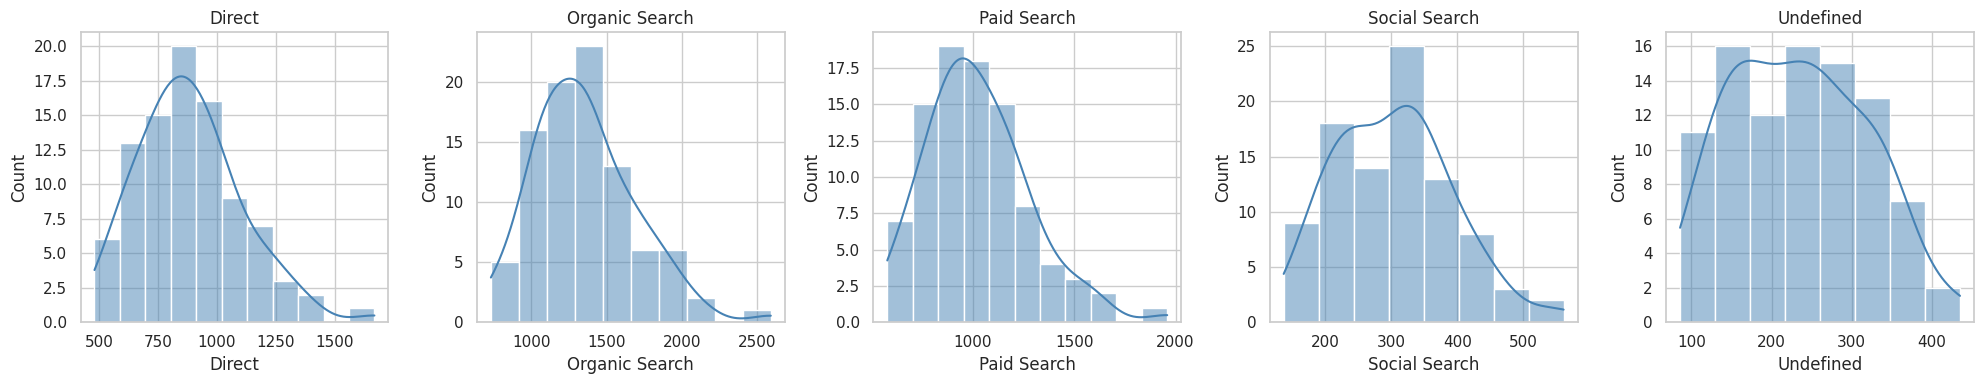

Shapiro-Wilk (Direct): statistic=0.970, p-value=0.03428
Shapiro-Wilk (Organic Search): statistic=0.964, p-value=0.01227
Shapiro-Wilk (Paid Search): statistic=0.963, p-value=0.01083
Shapiro-Wilk (Social Search): statistic=0.979, p-value=0.14127
Shapiro-Wilk (Undefined): statistic=0.973, p-value=0.05456

One-way ANOVA: statistic=439.768, p-value=0.00000
Kruskal-Wallis test: statistic=368.981, p-value=0.00000


In [37]:
# --- Build daily session counts per traffic channel ---
daily_sessions_by_channel = (
    df.groupby(["session_date", "traffic_channel"])["ga_session_id"]
    .nunique()
    .unstack(fill_value=0)
)

# --- Visualize distributions ---
fig, axes = plt.subplots(1, len(daily_sessions_by_channel.columns), figsize=(20, 4))
for ax, col in zip(axes, daily_sessions_by_channel.columns):
    sns.histplot(daily_sessions_by_channel[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

# --- Step 1: Test normality for each channel (Shapiro-Wilk) ---
for col in daily_sessions_by_channel.columns:
    stat, p_value = stats.shapiro(daily_sessions_by_channel[col])
    print(f"Shapiro-Wilk ({col}): statistic={stat:.3f}, p-value={p_value:.5f}")

# --- Step 2: Choose test based on normality results ---
# If all groups are normal -> one-way ANOVA
# If at least one group is NOT normal -> Kruskal-Wallis test (non-parametric alternative)

samples = [daily_sessions_by_channel[col] for col in daily_sessions_by_channel.columns]

stat_normal, p_normal = stats.f_oneway(*samples)
stat_kw, p_kw = stats.kruskal(*samples)

print(f"\nOne-way ANOVA: statistic={stat_normal:.3f}, p-value={p_normal:.5f}")
print(f"Kruskal-Wallis test: statistic={stat_kw:.3f}, p-value={p_kw:.5f}")

Out of 5 channels, three (Direct, Organic Search, Paid Search) have p-value < 0.05 in the Shapiro-Wilk test — meaning their distributions are statistically non-normal, while two (Social Search, Undefined) turned out normal (p>0.05). Since the "all groups must be normal" rule isn't satisfied, the Kruskal-Wallis test is the correct choice over ANOVA. The Kruskal-Wallis result shows a statistically significant difference between channels (p<0.00001) — meaning session counts genuinely differ by traffic channel, not just random spread around the same level. This confirms what was already visible in earlier charts — Organic Search and Paid Search generate substantially more sessions than Social Search or Undefined.

In [38]:
# --- Step 1: Build input data for the test ---
# For each region, count sessions with organic traffic_source vs all other sessions

europe_sessions = df[df["continent"] == "Europe"]
americas_sessions = df[df["continent"] == "Americas"]

europe_organic = (europe_sessions["traffic_source"] == "organic").sum()
europe_total = len(europe_sessions)

americas_organic = (americas_sessions["traffic_source"] == "organic").sum()
americas_total = len(americas_sessions)

europe_organic_share = round(europe_organic / europe_total * 100, 2)
americas_organic_share = round(americas_organic / americas_total * 100, 2)

print(f"Europe: {europe_organic} organic sessions out of {europe_total} "
      f"({europe_organic_share}%)")
print(f"Americas: {americas_organic} organic sessions out of {americas_total} "
      f"({americas_organic_share}%)")

# --- Step 2: Build contingency table ---
contingency_table = [
    [europe_organic, europe_total - europe_organic],
    [americas_organic, americas_total - americas_organic]
]

# --- Step 3: Run Chi-Squared test for proportions ---
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-Squared test: statistic={chi2_stat:.3f}, p-value={p_value:.5f}")

Europe: 22190 organic sessions out of 65135 (34.07%)
Americas: 65783 organic sessions out of 193179 (34.05%)

Chi-Squared test: statistic=0.004, p-value=0.94873


The share of sessions with organic traffic is nearly identical in both regions — Europe (34.07%) and Americas (34.05%), a difference of just 0.02 pp. The Chi-Squared test confirms this minimal difference is not statistically significant (p=0.94873, far above the 0.05 threshold) — meaning the organic traffic share is effectively the same in both regions, and the observed difference is due to ordinary sampling randomness rather than a real regional difference in search engine behavior or SEO effectiveness.

In [39]:
from statsmodels.stats.proportion import proportions_ztest

desktop_purchases = purchases[purchases["device"] == "desktop"]
mobile_purchases = purchases[purchases["device"] == "mobile"]

desktop_expensive = (desktop_purchases["product_price"] > 1000).sum()
desktop_total = len(desktop_purchases)

mobile_expensive = (mobile_purchases["product_price"] > 1000).sum()
mobile_total = len(mobile_purchases)

desktop_share = round(desktop_expensive / desktop_total * 100, 2)
mobile_share = round(mobile_expensive / mobile_total * 100, 2)

print(f"Desktop: {desktop_expensive} expensive orders out of {desktop_total} ({desktop_share}%)")
print(f"Mobile: {mobile_expensive} expensive orders out of {mobile_total} ({mobile_share}%)")

count = [desktop_expensive, mobile_expensive]
nobs = [desktop_total, mobile_total]

z_stat, p_value = proportions_ztest(count, nobs)
print(f"\nZ-test for proportions: z={z_stat:.3f}, p-value={p_value:.5f}")

Desktop: 5636 expensive orders out of 19702 (28.61%)
Mobile: 3662 expensive orders out of 13113 (27.93%)

Z-test for proportions: z=1.338, p-value=0.18075


The share of "expensive" orders (>1000 USD) is nearly identical across both devices — Desktop (28.61%) and Mobile (27.93%), a difference of just 0.68 pp. The Z-test for proportions shows this difference is not statistically significant (z=1.338, p=0.18075, well above the 0.05 threshold) — meaning there's no evidence that mobile users make expensive purchases less often than desktop users. This is an interesting result, as it disproves the intuitive assumption that mobile leads to cheaper, more "impulsive" purchases — in reality, the price-segment structure of purchases doesn't depend on device type.

In [40]:
device_continent_table = pd.crosstab(df["continent"], df["device"])
device_continent_table = device_continent_table.loc[["Americas", "Asia", "Europe"]]
print(device_continent_table)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(device_continent_table)
print(f"\nChi-Squared test: statistic={chi2_stat:.3f}, p-value={p_value:.5f}, degrees of freedom={dof}")

# Show device share (%) per continent for easier interpretation
device_continent_pct = (device_continent_table.div(device_continent_table.sum(axis=1), axis=0) * 100).round(2)
print("\nDevice share (%) by continent:")
print(device_continent_pct)

device     desktop  mobile  tablet
continent                         
Americas    113016   75889    4274
Asia         48442   32755    1916
Europe       38132   25517    1486

Chi-Squared test: statistic=3.722, p-value=0.44500, degrees of freedom=4

Device share (%) by continent:
device     desktop  mobile  tablet
continent                         
Americas     58.50   39.28    2.21
Asia         58.28   39.41    2.31
Europe       58.54   39.18    2.28


Device type distribution is nearly identical across all three continents — desktop ranges 58.28-58.54%, mobile 39.18-39.41%, tablet 2.21-2.31% regardless of region. The Chi-Squared test confirms these minimal differences are not statistically significant (p=0.44500, far above the 0.05 threshold) — meaning device type and continent are independent variables. This suggests device preference (desktop/mobile/tablet) doesn't depend on user geography — global device-choice behavior for shopping is universal, without regional specificity.

## Interactive Tableau Dashboard

**[View Tableau Dashboard](https://public.tableau.com/your-link-here)**

## Summary & Key Takeaways

### Main Business Patterns
* **Search channels drive most sales:** Organic Search (~35.8%) and Paid Search (~26.6%) are the main engines here, together bringing in over 60% of total revenue. Social channels currently contribute very little (~7.9%).
* **Desktop vs. Mobile:** Desktop users still generate the majority of sales and convert better. Even though mobile gets a solid amount of traffic, users are less likely to finish their purchases on mobile devices.
* **Q4 Peak:** Sales are fairly stable throughout the year, but jump significantly in November and December due to Black Friday and holiday shopping.

### What the Statistics Tell Us
* **No regional differences in devices:** Geographic location doesn't really impact device choice ($p > 0.05$). The preference pattern is pretty uniform across all market regions.
* **Order values are equal across devices:** A Chi-Square test showed that the share of high-ticket purchases is basically the same on Mobile and Desktop ($p = 0.18$). The lower overall mobile revenue is a conversion issue, not a sign that mobile users buy cheaper items.

### Practical Next Steps
1. **Focus budget on Search:** Prioritize SEO and Google Ads over social channels, as search intent clearly drives the highest conversion for this store.
2. **Fix Mobile Checkout:** Audit the mobile user journey to reduce drop-offs during checkout and narrow the conversion gap with Desktop.
3. **Prepare for Q4 Early:** Scale up advertising campaigns starting in late October to fully capture the end-of-year sales peak.